In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

In [2]:
def u0(x):
    if 0.4 <= x <= 0.6:
        return np.sin(5 * np.pi * x)
    else:
        return 0

In [3]:
def u1(x):
    return 0


def u_left(t):
    return 0


def u_right(t):
    return 0

In [6]:
a = 0
b = 1
t_0 = 0
T = 20
c = 1
N = 50
M = 1000
h = (b - a) / N
x = np.linspace(a, b, N + 1)
tau = (T - t_0) / M
t = np.linspace(t_0, T, M + 1)
u = np.zeros((M + 1, N + 1))

In [7]:
# implicit
for n in range(N + 1):
    u[0, n] = u0(x[n])

for n in range(1, N):
    u[1, n] = u[0, n] + tau * u1(x[n]) + 0.5 * (c ** 2) * (tau ** 2 / h ** 2) * (
            u[0, n + 1] - 2 * u[0, n] + u[0, n - 1])

u[1, 0] = u_left(t[1])
u[1, N] = u[1, N - 1]

In [8]:
for m in range(1, M):
    u[m + 1, 0] = u_left(t[m + 1])
    for n in range(1, N):
        u[m + 1, n] = -u[m - 1, n] + 2 * u[m, n] + c ** 2 * tau ** 2 / h ** 2 * (
                u[m, n + 1] - 2 * u[m, n] + u[m, n - 1])
    u[m + 1, N] = u[m + 1, N - 1]

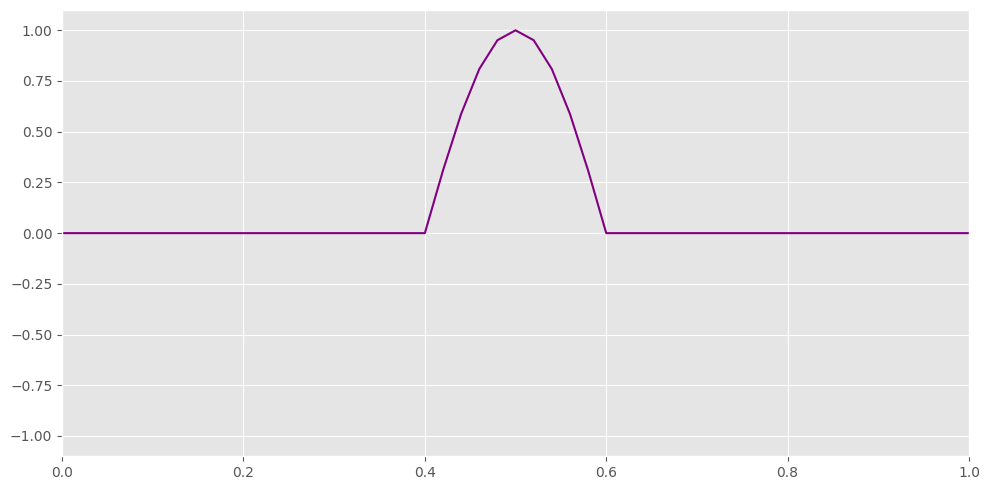

In [16]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot(x, u[0, :], color='purple')

ax.set_ylim(-1.1, 1.1)
ax.set_xlim(0, 1)
ax.grid(True)


def animate(frame):
    line.set_ydata(u[frame * 5, :])
    return line,


anim = FuncAnimation(fig, animate, frames=min(200, M // 5), interval=100, blit=True)
plt.tight_layout()
plt.show()

In [17]:
from IPython.display import HTML

HTML(anim.to_jshtml())